In [108]:
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

There were errors with test 11 and test 3, so they are missing from our data set

In [109]:
# Extract data from summary.xlsx

df = pd.read_excel("summary.xlsx",sheet_name="General")
ch0,ch1,ch2,aggreg = df['Channel 0'], df['Channel 1'], df['Channel 2'], df['All Channels']
event_rate = []
for ch in [ch0,ch1,ch2,aggreg]:
   ch_event_rate = np.array(ch)[3::5]
   ch_event_rate = np.array([np.array(er.split(" ± "),dtype=np.float64) for er in ch_event_rate])
   event_rate.append(ch_event_rate)
event_rate = np.array(event_rate)
print(event_rate.shape)

n_events = []
for ch in [ch0,ch1,ch2,aggreg]:
   ch_n_events = np.array(ch)[1::5]
   n_events.append(ch_n_events)
n_events = np.array(n_events)
print(n_events.shape)



(4, 18, 2)
(4, 18)


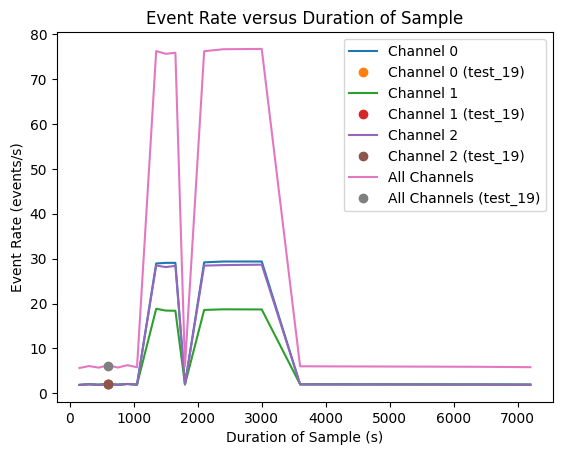

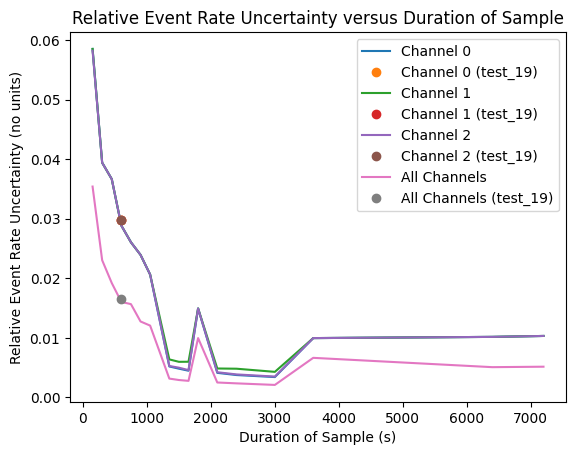

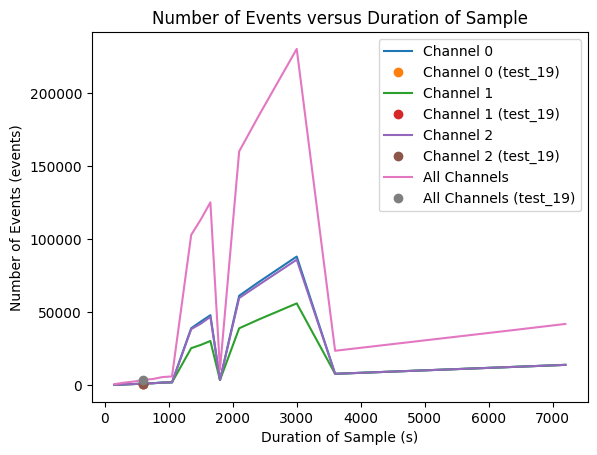

In [110]:
durations = np.array([7200,6400,3600,3000,2400,2100,1800,1650,1500,1350,1050,900,750,600,450,300,150,600])

plt.title(f"Event Rate versus Duration of Sample")
plt.ylabel("Event Rate (events/s)")
plt.xlabel("Duration of Sample (s)")
for i in range(len(event_rate)):
   if i == 3:
      plt.plot(durations[:17],event_rate[i][:17,0],label=f"All Channels")
      plt.plot(durations[17],event_rate[i][17,0],label=f"All Channels (test_19)",marker = 'o',linestyle = '')
   else:
      plt.plot(durations[:17],event_rate[i][:17,0],label=f"Channel {i}")
      plt.plot(durations[17],event_rate[i][17,0],label=f"Channel {i} (test_19)",marker = 'o',linestyle = '')
plt.legend()
plt.show()

plt.title(f"Relative Event Rate Uncertainty versus Duration of Sample")
plt.ylabel("Relative Event Rate Uncertainty (no units)")
plt.xlabel("Duration of Sample (s)")
for i in range(len(event_rate)):
   if i == 3:
      plt.plot(durations[:17],event_rate[i][:17,1]/event_rate[i][:17,0],label=f"All Channels")
      plt.plot(durations[17],event_rate[i][17,1]/event_rate[i][17,0],label=f"All Channels (test_19)",marker = 'o',linestyle = '')
   else:
      plt.plot(durations[:17],event_rate[i][:17,1]/event_rate[i][:17,0],label=f"Channel {i}")
      plt.plot(durations[17],event_rate[i][17,1]/event_rate[i][17,0],label=f"Channel {i} (test_19)",marker = 'o',linestyle = '')
plt.legend()
plt.show()

plt.title(f"Number of Events versus Duration of Sample")
plt.ylabel("Number of Events (events)")
plt.xlabel("Duration of Sample (s)")
for i in range(len(n_events)):
   if i == 3:
      plt.plot(durations[:17],n_events[i][:17],label=f"All Channels")
      plt.plot(durations[17],n_events[i][17],label=f"All Channels (test_19)",marker = 'o',linestyle = '')
   else:
      plt.plot(durations[:17],n_events[i][:17],label=f"Channel {i}")
      plt.plot(durations[17],n_events[i][17],label=f"Channel {i} (test_19)",marker = 'o',linestyle = '')
plt.legend()
plt.show()

Good data points are <=1050 and >=3600

[ 600  150  300  450  600  750  900 1050 1800 3600 6400 7200]
[3615 825 1815 2565 3720 4305 5640 6090 10845 23640 37860 42000]


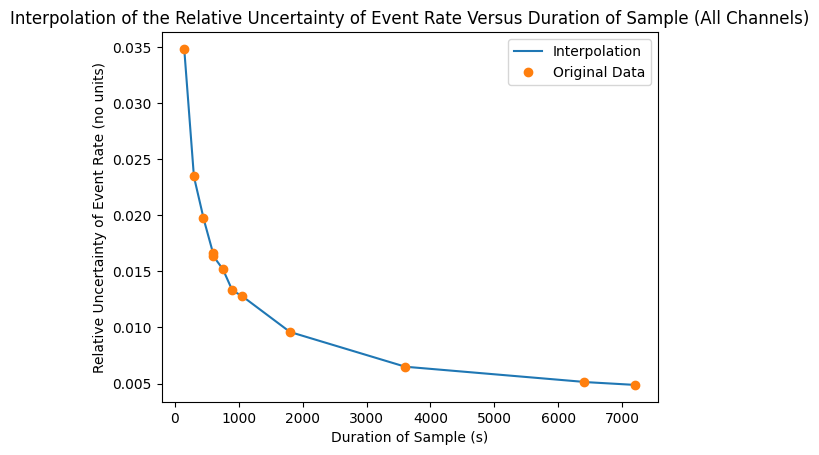

In [111]:
from scipy.interpolate import interp1d

mask = (durations >= 3600) | (durations <= 1050) | (durations == 1800)
cut_durations = np.flip(durations[mask])
cut_event_rate = np.flip(event_rate[3][mask])
cut_n_events = np.flip(n_events[3][mask])

print(cut_durations)
print(cut_n_events)

agg_interp = interp1d(cut_durations,[1/np.sqrt(num) for num in cut_n_events])

x = np.linspace(150,7200,2000)
plt.title("Interpolation of the Relative Uncertainty of Event Rate Versus Duration of Sample (All Channels)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample (s)")
plt.plot(x,agg_interp(x),label="Interpolation")
plt.plot(cut_durations,[1/np.sqrt(num) for num in cut_n_events],label="Original Data",marker="o",linestyle="")
plt.legend()
plt.show()

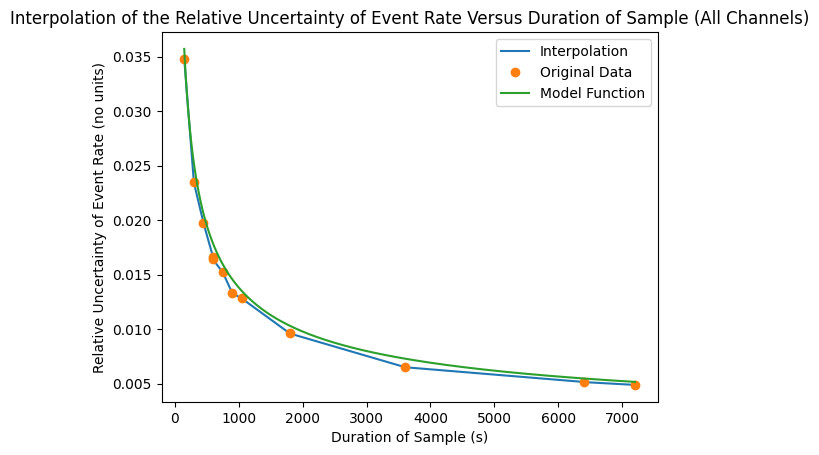

In [112]:
def f(x,a=0.035/0.08):
   return 1/np.sqrt(x) * a

plt.title("Interpolation of the Relative Uncertainty of Event Rate Versus Duration of Sample (All Channels)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample (s)")
plt.plot(x,agg_interp(x),label="Interpolation")
plt.plot(cut_durations,[1/np.sqrt(num) for num in cut_n_events],label="Original Data",marker="o",linestyle="")
plt.plot(x,f(x),label="Model Function")
plt.legend()
plt.show()

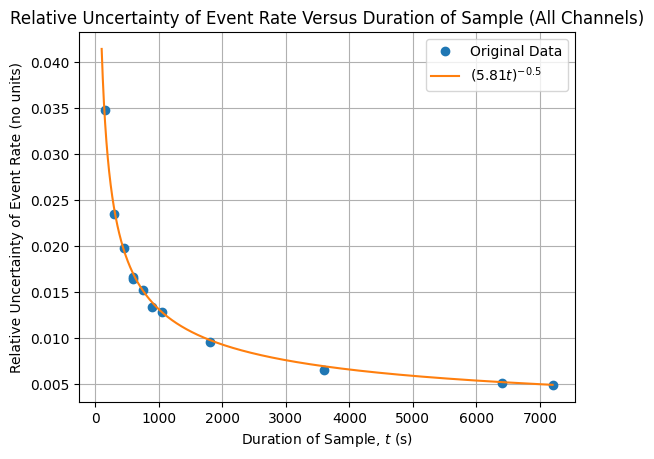

In [142]:
from scipy.optimize import curve_fit

def g(x,b):
   return 1 / np.sqrt(x * b)

popt,pcov = curve_fit(g,cut_durations,[1/np.sqrt(num) for num in cut_n_events],p0=[0.035/0.08])

x = np.linspace(100,7200,2000)
plt.title("Relative Uncertainty of Event Rate Versus Duration of Sample (All Channels)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample, $t$ (s)")
plt.plot(cut_durations,[1/np.sqrt(num) for num in cut_n_events],label="Original Data",marker="o",linestyle="")
plt.plot(x,g(x, *popt),label=f"({popt[0]:.2f}"+r"$t)^{-0.5}$")
plt.grid()
plt.legend()
plt.show()

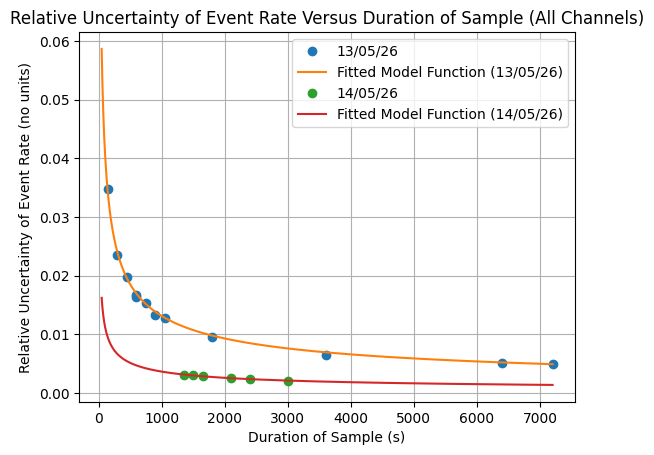

In [116]:
mask2 = (durations < 3600) & (durations > 1050) & (durations != 1800)
cut_durations2 = np.flip(durations[mask2])
cut_event_rate2 = np.flip(event_rate[3][mask2])
cut_n_events2 = np.flip(n_events[3][mask2])

popt2,pcov2 = curve_fit(g,cut_durations2,[1/np.sqrt(num) for num in cut_n_events2],p0=[0.035/0.08])

x = np.linspace(50,7200,2000)
plt.title("Relative Uncertainty of Event Rate Versus Duration of Sample (All Channels)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample (s)")
plt.plot(cut_durations,[1/np.sqrt(num) for num in cut_n_events],label="13/05/26",marker="o",linestyle="")
plt.plot(x,g(x, *popt),label="Fitted Model Function (13/05/26)")
plt.plot(cut_durations2,[1/np.sqrt(num) for num in cut_n_events2],label="14/05/26",marker="o",linestyle="")
plt.plot(x,g(x, *popt2),label="Fitted Model Function (14/05/26)")
plt.grid()
plt.legend()
plt.show()

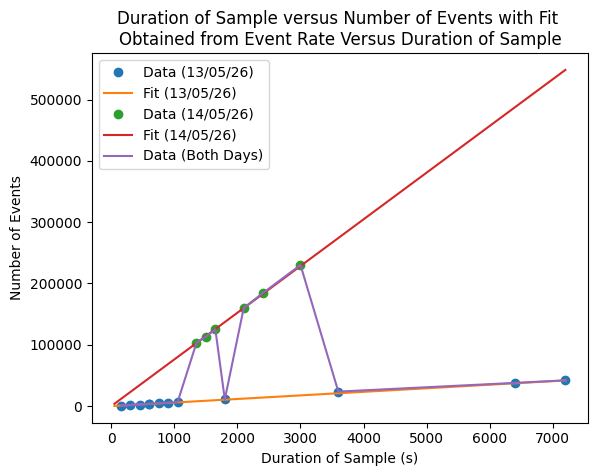

In [115]:
plt.title("Duration of Sample versus Number of Events with Fit \nObtained from Event Rate Versus Duration of Sample")
plt.ylabel("Number of Events")
plt.xlabel("Duration of Sample (s)")
plt.plot(cut_durations,cut_n_events,marker="o",linestyle="",label="Data (13/05/26)")
plt.plot(x,x * popt,label="Fit (13/05/26)")
plt.plot(cut_durations2,cut_n_events2,marker="o",linestyle="",label="Data (14/05/26)")
plt.plot(x,x * popt2,label="Fit (14/05/26)")
plt.plot(durations,n_events[i],label=f"Data (Both Days)")
plt.legend()
plt.show()

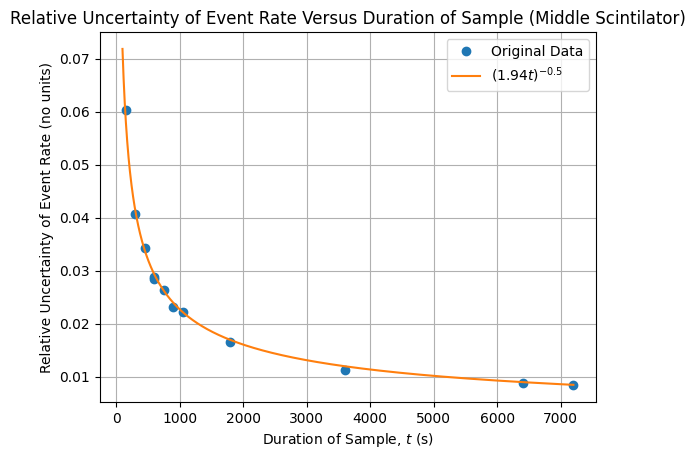

In [145]:
mask = (durations >= 3600) | (durations <= 1050) | (durations == 1800)
cut_durations = np.flip(durations[mask])
cut_event_rate = np.flip(event_rate[1][mask])
cut_n_events = np.flip(n_events[1][mask])

popt,pcov = curve_fit(g,cut_durations,[1/np.sqrt(num) for num in cut_n_events],p0=[2])

x = np.linspace(100,7200,2000)
plt.title("Relative Uncertainty of Event Rate Versus Duration of Sample (Middle Scintilator)")
plt.ylabel("Relative Uncertainty of Event Rate (no units)")
plt.xlabel("Duration of Sample, $t$ (s)")
plt.plot(cut_durations,[1/np.sqrt(num) for num in cut_n_events],label="Original Data",marker="o",linestyle="")
plt.plot(x,g(x, *popt),label=f"({popt[0]:.2f}"+r"$t)^{-0.5}$")
plt.grid()
plt.legend()
plt.show()

Collection 1:
150, 300, 450, 600, 750, 900, 1050, 1800, 3600, 6400, 7200
Collection 2:
1350,1500, 1650, 2100, 2400, 3000

I don't actually remember all of the ones that I did on which day

I think the order that I did them in was 7200, 6400, 3600, 1800, 900, 600, 300, 150, 450, 750, 1050, 1200, 1350, 1500, 1650, 2100, 2400, 3000, 3300

Samples were taken over two days, the 13th and the 14th.


COULD I HAVE MADE A MISTAKE?!?! The numbers seem really fishy for 14/05/26 (1000 events/s)

### Working with LanGauss Parameters

In [156]:
df = pd.read_excel("summary.xlsx",sheet_name="Landau-Gaussian Height")
chi2ndof,c,mu,mean,std,sigma_c,sigma_mu,sigma_mean,sigma_std = df['Chi-Squared per NDOF Statistic'], df['c'], df['mu'], df['mean'], df['std'], df['sigma_c'], df['sigma_mu'], df['sigma_mean'], df['sigma_std']

arr = []
for i in range(4):
   subarr=[]
   for j in range(18):
      k = i*18+j
      subarr.append(np.array([chi2ndof[k],c[k],mu[k],mean[k],std[k],sigma_c[k],sigma_mu[k],sigma_mean[k],sigma_std[k]]))
   arr.append(np.transpose(np.array(subarr)))
langaus = np.roll(np.array(arr),-1)
print(langaus.shape)

(4, 9, 18)


[ True  True  True False False False  True False False False  True  True
  True  True  True  True  True  True]
[ True  True  True False False False  True False False False  True  True
  True  True  True  True  True False]


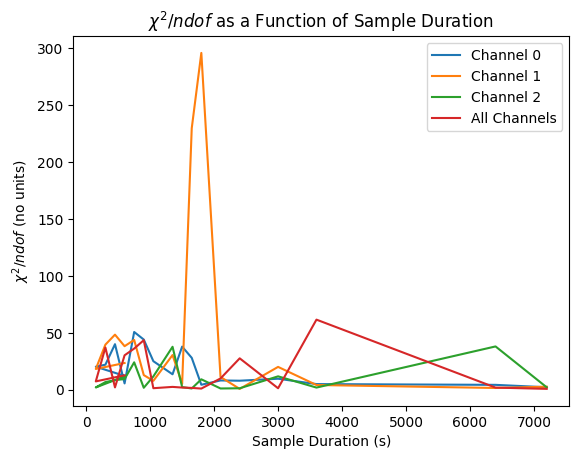

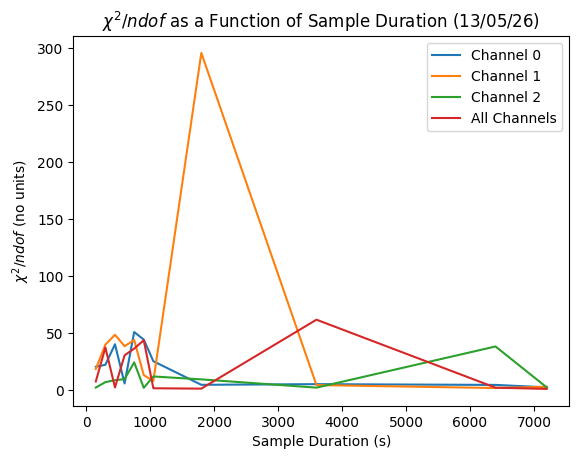

In [161]:
new_mask = np.append(mask[:-1],False)
print(mask)
print(new_mask)

plt.title(r"$\chi^2/ndof$ as a Function of Sample Duration")
plt.ylabel(r"$\chi^2/ndof$ (no units)")
plt.xlabel("Sample Duration (s)")
for i in range(3):
   plt.plot(durations,langaus[i][0],label=f"Channel {i}")
plt.plot(durations,langaus[3][0],label=f"All Channels")   
plt.legend()
plt.show()

plt.title(r"$\chi^2/ndof$ as a Function of Sample Duration (13/05/26)")
plt.ylabel(r"$\chi^2/ndof$ (no units)")
plt.xlabel("Sample Duration (s)")
for i in range(3):
   plt.plot(durations[new_mask],langaus[i][0][new_mask],label=f"Channel {i}")
plt.plot(durations[new_mask],langaus[3][0][new_mask],label=f"All Channels")   
plt.legend()
plt.show()

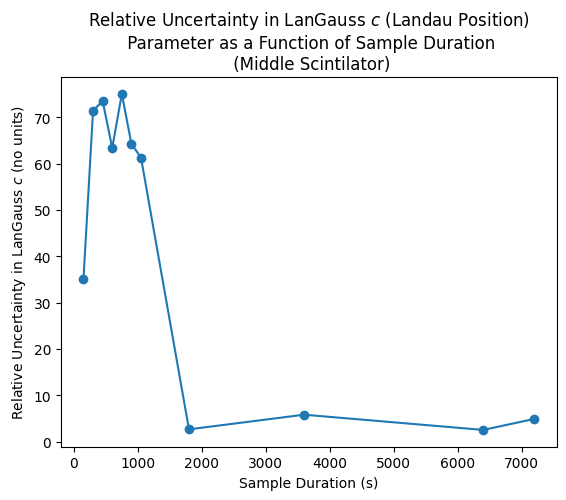

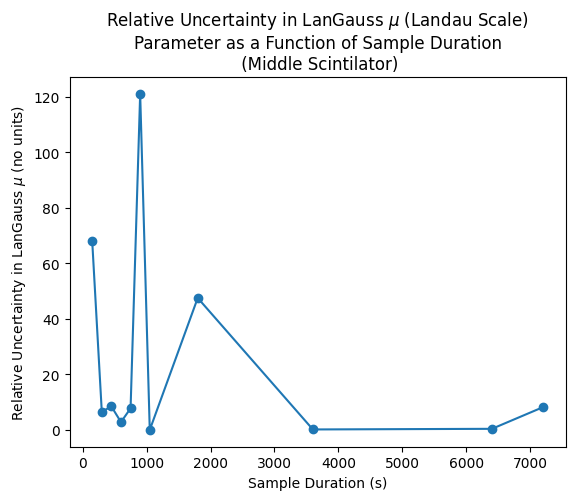

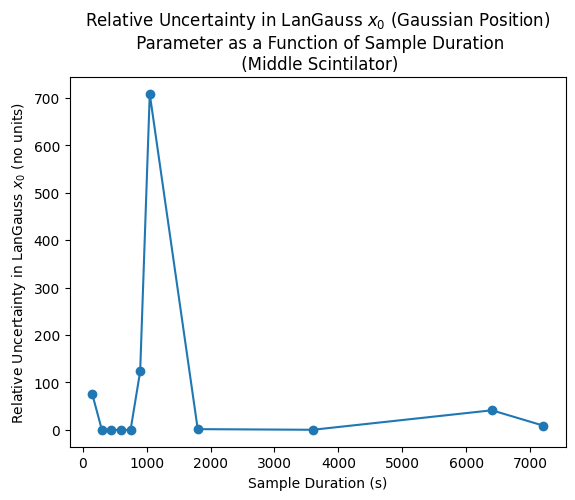

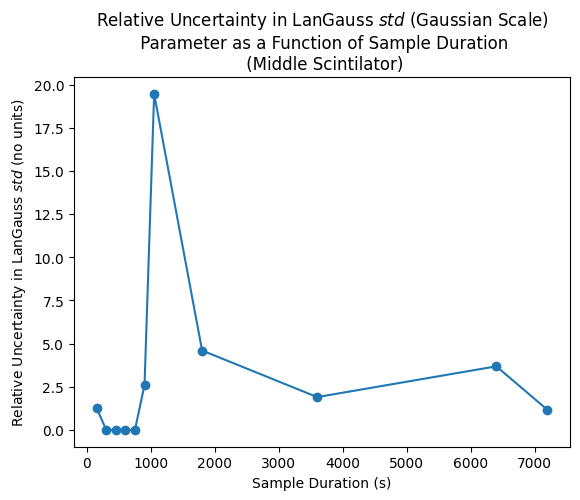

In [162]:
plt.title("Relative Uncertainty in LanGauss $c$ (Landau Position)\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in LanGauss $c$ (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],langaus[1][1][new_mask]/langaus[1][5][new_mask],marker="o")
plt.show()

plt.title(r"Relative Uncertainty in LanGauss $\mu$ (Landau Scale)"+"\nParameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel(r"Relative Uncertainty in LanGauss $\mu$ (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],langaus[1][2][new_mask]/langaus[1][6][new_mask],marker="o")
plt.show()

plt.title("Relative Uncertainty in LanGauss $x_0$ (Gaussian Position)\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in LanGauss $x_0$ (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],langaus[1][3][new_mask]/langaus[1][7][new_mask],marker="o")
plt.show()

plt.title("Relative Uncertainty in LanGauss $std$ (Gaussian Scale)\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in LanGauss $std$ (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],langaus[1][4][new_mask]/langaus[1][8][new_mask],marker="o")
plt.show()

In [174]:
df = pd.read_excel("summary.xlsx",sheet_name="Exponentially Modified Gaussian Energy")
chi2ndof,K,mean,std,sigma_K,sigma_mean,sigma_std,thresh = df['Chi-Squared per NDOF Statistic'], df['K'], df['mean'], df['std'], df['sigma_K'], df['sigma_mean'], df['sigma_std'], df['0.10% Threshold']

arr = []
for i in range(4):
   subarr=[]
   for j in range(18):
      k = i*18+j
      subarr.append(np.array([chi2ndof[k],K[k],mean[k],std[k],sigma_K[k],sigma_mean[k],sigma_std[k]]))
   arr.append(np.transpose(np.array(subarr)))
emodE = np.roll(np.array(arr),-1)
print(emodE.shape)

(4, 7, 18)


[ True  True  True False False False  True False False False  True  True
  True  True  True  True  True  True]
[ True  True  True False False False  True False False False  True  True
  True  True  True  True  True False]


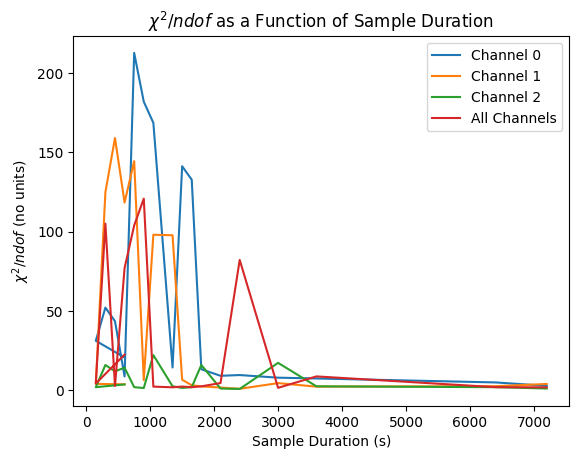

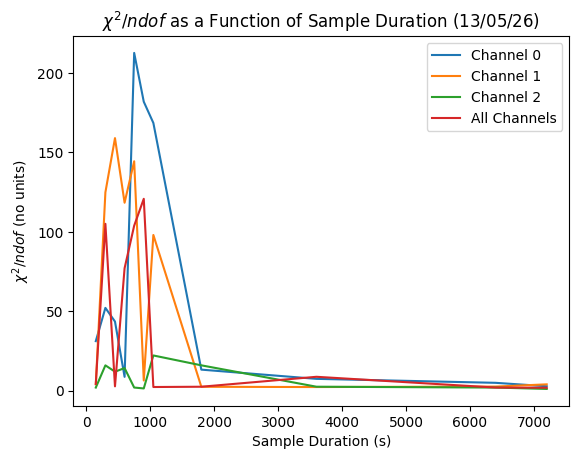

In [175]:
new_mask = np.append(mask[:-1],False)
print(mask)
print(new_mask)

plt.title(r"$\chi^2/ndof$ as a Function of Sample Duration")
plt.ylabel(r"$\chi^2/ndof$ (no units)")
plt.xlabel("Sample Duration (s)")
for i in range(3):
   plt.plot(durations,emodE[i][0],label=f"Channel {i}")
plt.plot(durations,emodE[3][0],label=f"All Channels")   
plt.legend()
plt.show()

plt.title(r"$\chi^2/ndof$ as a Function of Sample Duration (13/05/26)")
plt.ylabel(r"$\chi^2/ndof$ (no units)")
plt.xlabel("Sample Duration (s)")
for i in range(3):
   plt.plot(durations[new_mask],emodE[i][0][new_mask],label=f"Channel {i}")
plt.plot(durations[new_mask],emodE[3][0][new_mask],label=f"All Channels")   
plt.legend()
plt.show()

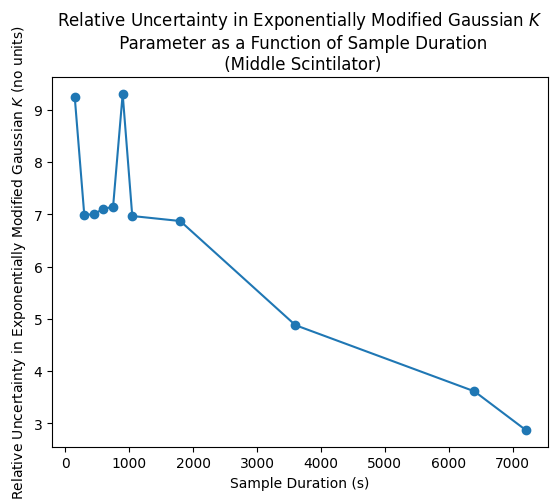

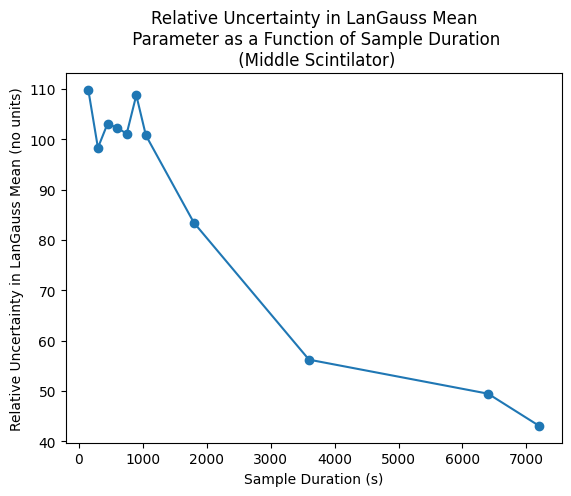

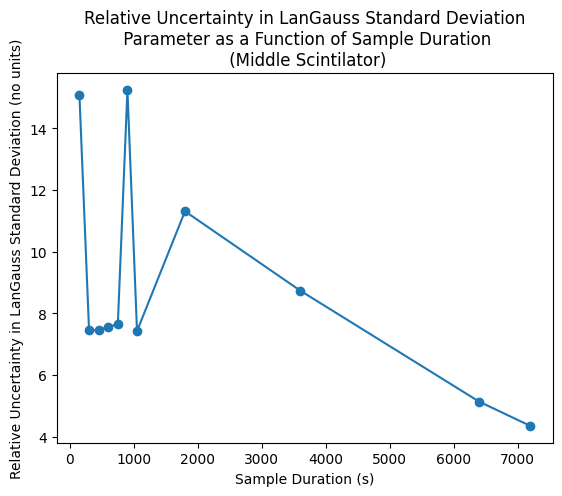

In [176]:
plt.title("Relative Uncertainty in Exponentially Modified Gaussian $K$\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in Exponentially Modified Gaussian $K$ (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],emodE[1][1][new_mask]/emodE[1][4][new_mask],marker="o")
plt.show()

plt.title("Relative Uncertainty in LanGauss Mean\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in LanGauss Mean (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],emodE[1][2][new_mask]/emodE[1][5][new_mask],marker="o")
plt.show()

plt.title("Relative Uncertainty in LanGauss Standard Deviation\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in LanGauss Standard Deviation (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],emodE[1][3][new_mask]/emodE[1][6][new_mask],marker="o")
plt.show()

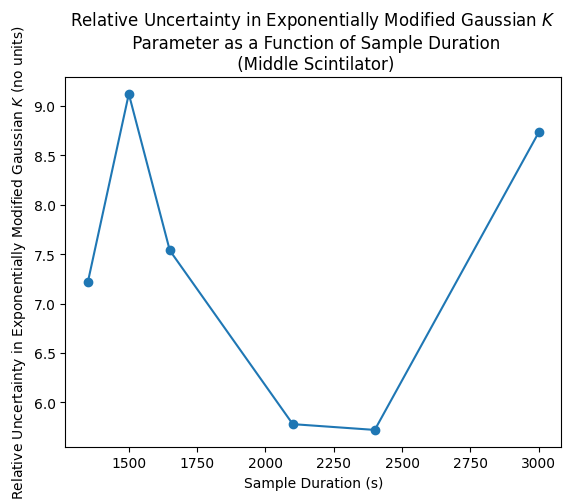

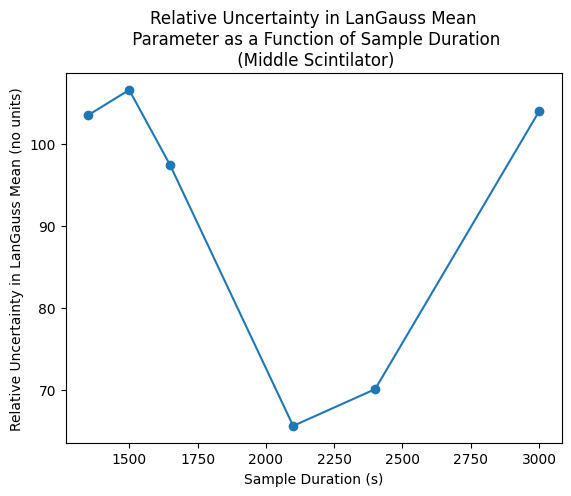

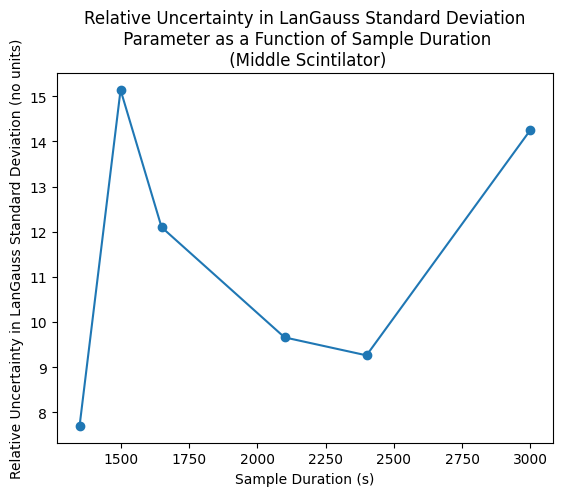

In [ ]:
plt.title("Relative Uncertainty in Exponentially Modified Gaussian $K$\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in Exponentially Modified Gaussian $K$ (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[mask2],emodE[1][1][mask2]/emodE[1][4][mask2],marker="o")
plt.show()

plt.title("Relative Uncertainty in LanGauss Mean\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in LanGauss Mean (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[mask2],emodE[1][2][mask2]/emodE[1][5][mask2],marker="o")
plt.show()

plt.title("Relative Uncertainty in LanGauss Standard Deviation\n Parameter as a Function of Sample Duration\n (Middle Scintilator)")
plt.ylabel("Relative Uncertainty in LanGauss Standard Deviation (no units)")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[mask2],emodE[1][3][mask2]/emodE[1][6][mask2],marker="o")
plt.show()

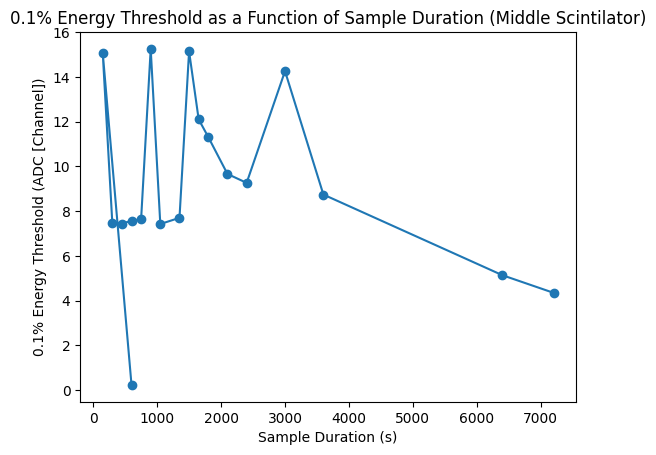

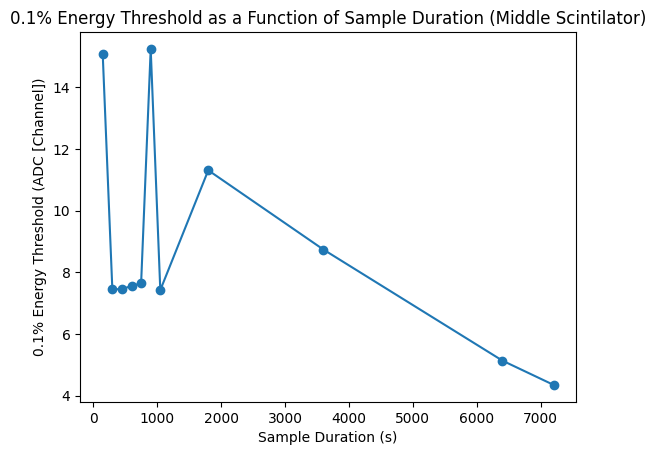

In [180]:
plt.title("0.1% Energy Threshold as a Function of Sample Duration (Middle Scintilator)")
plt.ylabel("0.1% Energy Threshold (ADC [Channel])")
plt.xlabel("Sample Duration (s)")
plt.plot(durations,emodE[1][3]/emodE[1][6],marker="o")
plt.show()

plt.title("0.1% Energy Threshold as a Function of Sample Duration (Middle Scintilator)")
plt.ylabel("0.1% Energy Threshold (ADC [Channel])")
plt.xlabel("Sample Duration (s)")
plt.plot(durations[new_mask],emodE[1][3][new_mask]/emodE[1][6][new_mask],marker="o")
plt.show()